In [ ]:
install.packages(c("sqldf", "ggplot2", "dplyr", "readr", "corrplot"),
                 repos = "https://cran.rstudio.com/")

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘gsubfn’, ‘proto’, ‘RSQLite’, ‘chron’




In [ ]:
library(sqldf)    # SQL on data frames
library(ggplot2)  # Visualisations
library(dplyr)    # Data manipulation helpers
library(readr)    # Fast CSV reading
library(corrplot) # Correlation matrix (optional)

Loading required package: gsubfn

Loading required package: proto

Warning message:
“no DISPLAY variable so Tk is not available”
Loading required package: RSQLite


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


corrplot 0.95 loaded



In [ ]:
orders       <- read_csv("orders.csv", show_col_types = FALSE)
deliveries   <- read_csv("deliveries.csv", show_col_types = FALSE)
customers    <- read_csv("customers.csv", show_col_types = FALSE)
drivers      <- read_csv("drivers.csv", show_col_types = FALSE)
vehicles     <- read_csv("vehicles.csv", show_col_types = FALSE)
hubs         <- read_csv("hubs.csv", show_col_types = FALSE)
complaints   <- read_csv("complaints.csv", show_col_types = FALSE)
incidents    <- read_csv("incidents.csv", show_col_types = FALSE)
app_events   <- read_csv("app_events.csv", show_col_types = FALSE)

In [ ]:
cat("Orders:", dim(orders), "\n")
cat("Deliveries:", dim(deliveries), "\n")
cat("Customers:", dim(customers), "\n")
# ... etc.

Orders: 1250 11 
Deliveries: 950 13 
Customers: 650 9 


Standardise Inconsistent Zone Names

In [ ]:
zone_clean <- function(x) {
  x <- trimws(x)
  x <- gsub("^north$|^NORTH$", "North", x, ignore.case = TRUE)
  x <- gsub("^south$|^SOUTH$", "South", x, ignore.case = TRUE)
  x <- gsub("^east$|^EAST$", "East", x, ignore.case = TRUE)
  x <- gsub("^west$|^WEST$", "West", x, ignore.case = TRUE)
  x <- gsub("^Ctr$|^ctr$|^Central$|^CENTRAL$", "Central", x, ignore.case = TRUE)
  x <- gsub("^Airport$|^AIRPORT$", "Airport", x, ignore.case = TRUE)
  x <- gsub("^RiverSide$|^Riverside$", "Riverside", x, ignore.case = TRUE)
  return(x)
}

orders$pickup_zone      <- zone_clean(orders$pickup_zone)
orders$dropoff_zone     <- zone_clean(orders$dropoff_zone)
customers$home_zone     <- zone_clean(customers$home_zone)
drivers$base_zone       <- zone_clean(drivers$base_zone)
hubs$zone               <- zone_clean(hubs$zone)
vehicles$assigned_zone  <- zone_clean(vehicles$assigned_zone)
app_events$zone_context <- zone_clean(app_events$zone_context)

Query 1 – Delivery Performance by Dropoff Zone

In [ ]:
sql3 <- "
SELECT o.dropoff_zone,
       COUNT(*) AS total_orders,
       SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1 ELSE 0 END) AS failures,
       ROUND(100.0 * SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1 ELSE 0 END) / COUNT(*), 1) AS failure_pct,

       SUM(CASE WHEN d.delivery_status = 'OnTime' THEN 1 ELSE 0 END) AS ontime,
       ROUND(100.0 * SUM(CASE WHEN d.delivery_status = 'OnTime' THEN 1 ELSE 0 END) / COUNT(*), 1) AS ontime_pct,

       ROUND(AVG(d.customer_rating_post_delivery), 2) AS avg_rating
FROM orders o
JOIN deliveries d ON o.order_id = d.order_id
GROUP BY o.dropoff_zone
ORDER BY failure_pct DESC;
"
zone_detailed <- sqldf(sql3)
print(zone_detailed)

  dropoff_zone total_orders failures failure_pct ontime ontime_pct avg_rating
1        North          145       25        17.2     88       60.7       3.83
2      Central          147       25        17.0     86       58.5       3.77
3        South          130       18        13.8     87       66.9       3.85
4    Riverside          141       19        13.5     96       68.1       3.96
5         East          118       14        11.9     82       69.5       3.86
6         West          146       17        11.6    103       70.5       3.92
7      Airport          123       14        11.4     74       60.2       3.87


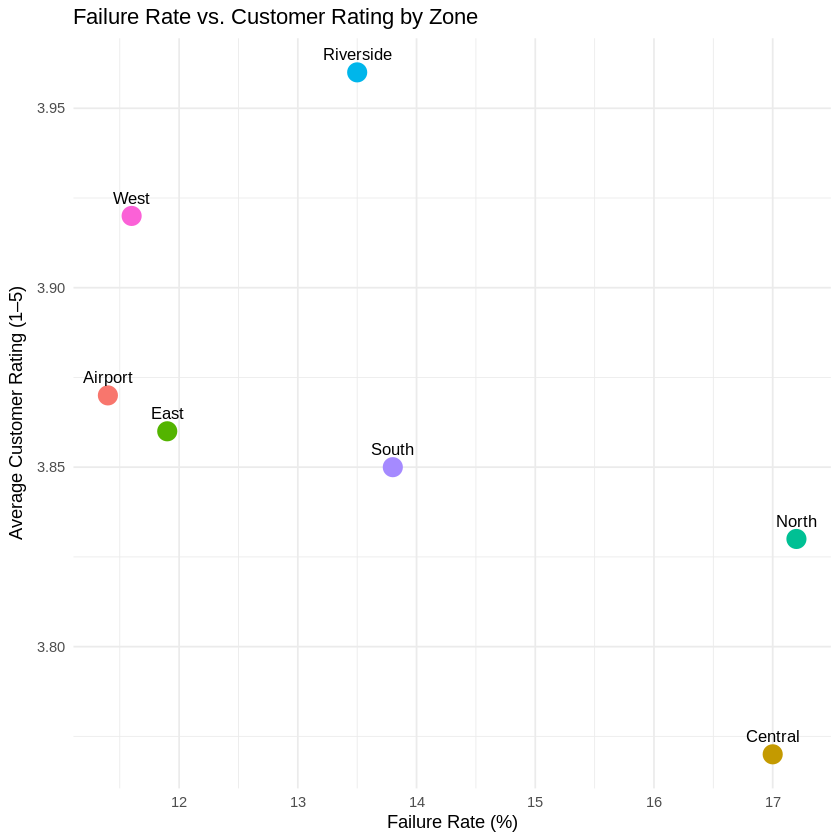

In [ ]:
ggplot(zone_perf, aes(x = failure_pct, y = avg_rating, color = dropoff_zone)) +
  geom_point(size = 5) +
  geom_text(aes(label = dropoff_zone), vjust = -1, size = 3.5, color = "black") +
  labs(title = "Failure Rate vs. Customer Rating by Zone",
       x = "Failure Rate (%)", y = "Average Customer Rating (1–5)") +
  theme_minimal() +
  theme(legend.position = "none")

Driver, Vehicle and Override Analysis

In [ ]:
sql2 <- "
SELECT o.dropoff_zone,
       COUNT(*) AS orders,
       ROUND(AVG(d.manual_route_override_count), 2) AS avg_overrides,
       ROUND(AVG(d.route_distance_km), 1) AS avg_km,
       ROUND(AVG(v.battery_health_pct), 1) AS avg_battery,
       ROUND(AVG(dr.driver_rating), 2) AS avg_driver_rating
FROM orders o
JOIN deliveries d ON o.order_id = d.order_id
JOIN drivers dr ON d.driver_id = dr.driver_id
JOIN vehicles v ON d.vehicle_id = v.vehicle_id
GROUP BY o.dropoff_zone
ORDER BY avg_overrides DESC;
"
zone_factors <- sqldf(sql2)
print(zone_factors)

  dropoff_zone orders avg_overrides avg_km avg_battery avg_driver_rating
1      Airport    123          1.01   14.3        74.0              4.12
2      Central    147          1.00   13.7        76.2              4.20
3        North    145          0.98   14.2        76.1              4.15
4         East    118          0.97   14.0        77.1              4.13
5         West    146          0.95   13.1        78.8              4.15
6    Riverside    141          0.95   14.3        77.9              4.21
7        South    130          0.92   13.9        78.4              4.17


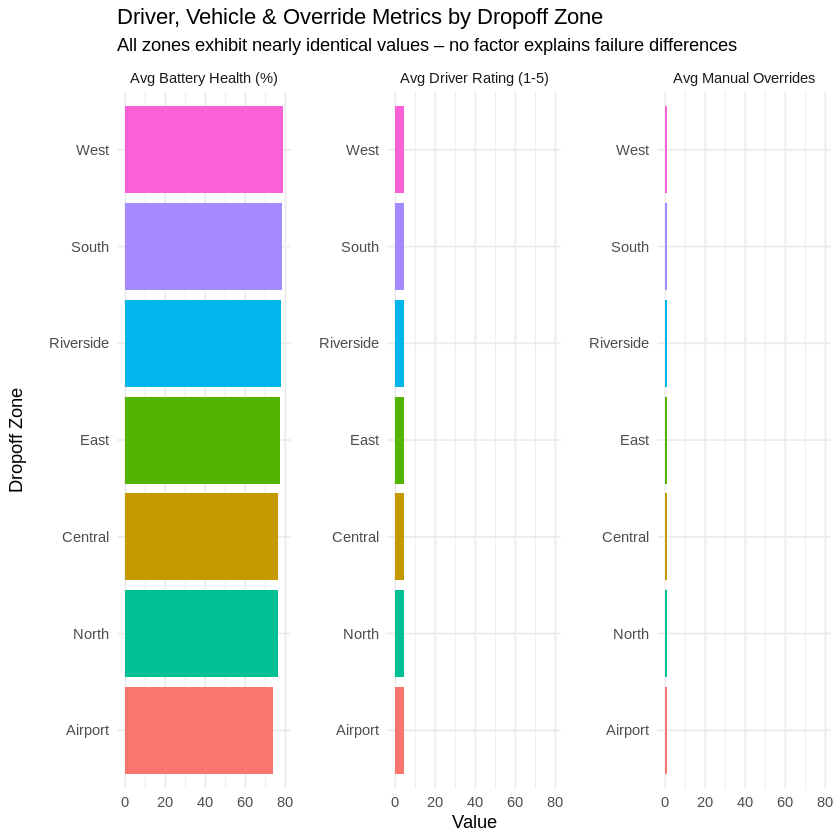

In [ ]:
library(ggplot2)
library(tidyr)

# Reshape the data into long format
zone_long <- zone_factors %>%
  select(dropoff_zone, avg_overrides, avg_battery, avg_driver_rating) %>%
  pivot_longer(cols = c(avg_overrides, avg_battery, avg_driver_rating),
               names_to = "metric", values_to = "value")

# Faceted bar chart
ggplot(zone_long, aes(x = reorder(dropoff_zone, value), y = value, fill = dropoff_zone)) +
  geom_col(show.legend = FALSE) +
  facet_wrap(~ metric, scales = "free_y",
             labeller = labeller(metric = c(
               "avg_overrides" = "Avg Manual Overrides",
               "avg_battery" = "Avg Battery Health (%)",
               "avg_driver_rating" = "Avg Driver Rating (1-5)"
             ))) +
  coord_flip() +
  labs(
    title = "Driver, Vehicle & Override Metrics by Dropoff Zone",
    subtitle = "All zones exhibit nearly identical values – no factor explains failure differences",
    x = "Dropoff Zone",
    y = "Value"
  ) +
  theme_minimal()

Promised Window Pressure

In [ ]:
sql3 <- "
SELECT o.dropoff_zone,
       ROUND(AVG(o.promised_window_hours), 1) AS avg_promise_hours,
       COUNT(*) AS orders
FROM orders o
JOIN deliveries d ON o.order_id = d.order_id
GROUP BY o.dropoff_zone
ORDER BY avg_promise_hours ASC;
"
promised <- sqldf(sql3)
print(promised)

  dropoff_zone avg_promise_hours orders
1        North               6.9    145
2    Riverside               7.0    141
3        South               7.3    130
4         East               7.8    118
5      Airport               7.9    123
6      Central               7.9    147
7         West               8.1    146


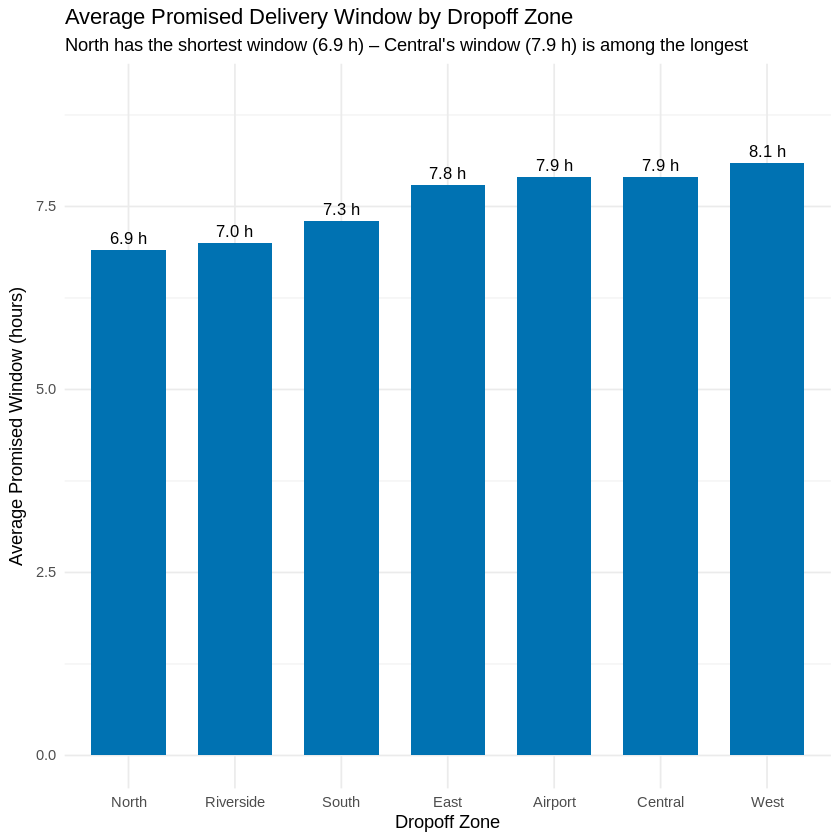

In [ ]:
library(ggplot2)

# Bar chart, zones ordered by avg_promise_hours (shortest to longest)
ggplot(promised, aes(x = reorder(dropoff_zone, avg_promise_hours),
                     y = avg_promise_hours)) +
  geom_col(fill = "#0072B2", width = 0.7) +
  geom_text(aes(label = sprintf("%.1f h", avg_promise_hours)),
            vjust = -0.5, size = 3.5) +   # add labels on top of bars
  labs(
    title = "Average Promised Delivery Window by Dropoff Zone",
    subtitle = "North has the shortest window (6.9 h) – Central's window (7.9 h) is among the longest",
    x = "Dropoff Zone",
    y = "Average Promised Window (hours)"
  ) +
  ylim(0, 9) +
  theme_minimal()

Service Type Mix

In [ ]:
sql4 <- "
SELECT o.dropoff_zone, o.service_type,
       COUNT(*) AS orders,
       ROUND(AVG(o.promised_window_hours), 1) AS avg_promise,
       SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1 ELSE 0 END) AS failures
FROM orders o
JOIN deliveries d ON o.order_id = d.order_id
WHERE o.dropoff_zone IN ('North', 'Central')
GROUP BY o.dropoff_zone, o.service_type
ORDER BY failures DESC;
"
service_mix <- sqldf(sql4)
print(service_mix)

   dropoff_zone service_type orders avg_promise failures
1         North    Passenger     43         8.1        9
2       Central      Medical     19         6.8        6
3       Central       Parcel     28         7.6        6
4         North       Retail     32         7.7        6
5       Central     Business     20         6.2        5
6       Central    Passenger     43         6.7        5
7         North     Business     15         4.5        4
8       Central       Retail     37        11.0        3
9         North      Medical     20         6.1        3
10        North       Parcel     35         6.0        3


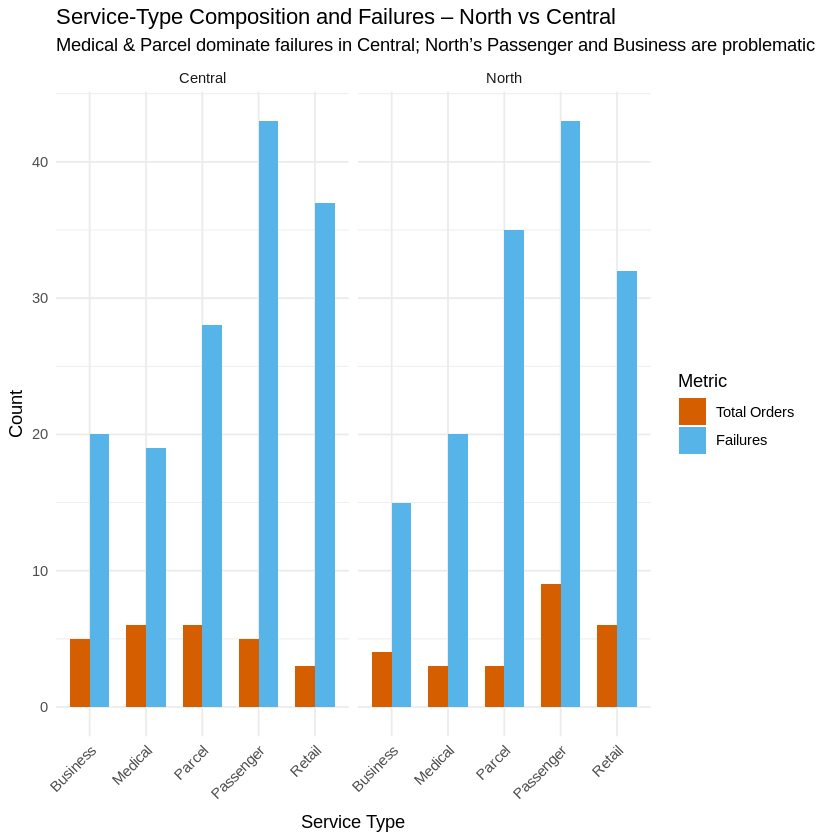

In [ ]:
library(ggplot2)
library(tidyr)

# Reshape so we can plot orders and failures side by side
sm_plot <- service_mix %>%
  pivot_longer(cols = c(orders, failures), names_to = "metric", values_to = "count")

ggplot(sm_plot, aes(x = service_type, y = count, fill = metric)) +
  geom_col(position = "dodge", width = 0.7) +
  facet_wrap(~ dropoff_zone, scales = "free_x") +
  scale_fill_manual(
    values = c("orders" = "#56B4E9", "failures" = "#D55E00"),
    labels = c("Total Orders", "Failures")
  ) +
  labs(
    title = "Service‑Type Composition and Failures – North vs Central",
    subtitle = "Medical & Parcel dominate failures in Central; North’s Passenger and Business are problematic",
    x = "Service Type",
    y = "Count",
    fill = "Metric"
  ) +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

Creating the master table

In [ ]:
library(sqldf)

master <- sqldf("
SELECT o.order_id, o.service_type, o.pickup_zone, o.dropoff_zone,
       o.promised_window_hours, o.priority_level, o.order_value,
       d.delivery_id, d.delivery_status, d.route_distance_km,
       d.manual_route_override_count, d.customer_rating_post_delivery,
       d.fuel_or_charge_cost,
       dr.driver_id, dr.driver_rating, dr.years_experience, dr.training_score,
       v.vehicle_id, v.vehicle_type, v.battery_health_pct,
       h.hub_name, h.hub_type, h.capacity_score
FROM orders o
LEFT JOIN deliveries d ON o.order_id = d.order_id
LEFT JOIN drivers dr ON d.driver_id = dr.driver_id
LEFT JOIN vehicles v ON d.vehicle_id = v.vehicle_id
LEFT JOIN hubs h ON d.hub_id = h.hub_id
")

Correlation Matrix of Performance Factors

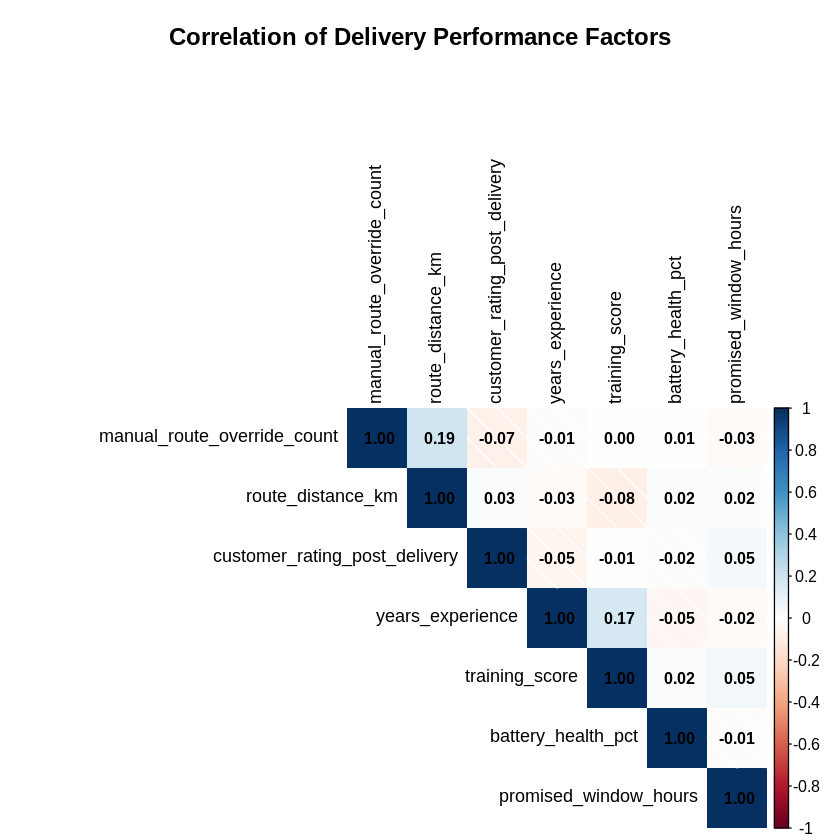

In [ ]:
library(dplyr)
library(corrplot)

num_data <- master %>%
  select(manual_route_override_count, route_distance_km,
         customer_rating_post_delivery, years_experience,
         training_score, battery_health_pct, promised_window_hours) %>%
  na.omit()

cor_matrix <- cor(num_data)
corrplot(cor_matrix, method = "shade", type = "upper",
         addCoef.col = "black", number.cex = 0.8,
         tl.col = "black", tl.cex = 0.9,
         title = "Correlation of Delivery Performance Factors",
         mar = c(0,0,3,0),
         cl.pos = "r")

Statistical Significance of Zone Differences

In [ ]:
# Create a binary grouping
master$zone_group <- ifelse(master$dropoff_zone %in% c("North","Central"),
                            "Problematic", "Others")

fail_zone_tbl <- table(master$zone_group, master$delivery_status)
# Only keep Failed and OnTime for a clean 2x2
fail_zone_tbl <- fail_zone_tbl[, c("Failed","OnTime")]
print(fail_zone_tbl)
chisq.test(fail_zone_tbl)

             
              Failed OnTime
  Others          82    442
  Problematic     50    174



	Pearson's Chi-squared test with Yates' continuity correction

data:  fail_zone_tbl
X-squared = 4.3593, df = 1, p-value = 0.03681


Customer Ratings by Dropoff Zone

Warning message:
“Removed 314 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 314 rows containing non-finite outside the scale range
(`stat_summary()`).”


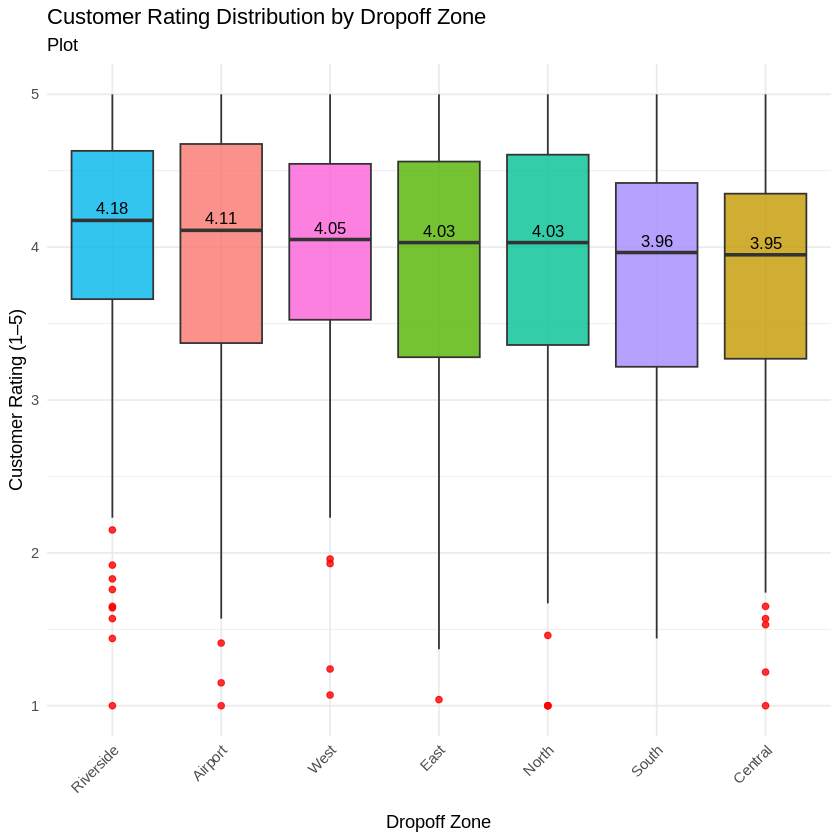

In [ ]:
library(ggplot2)

ggplot(master, aes(x = reorder(dropoff_zone, -customer_rating_post_delivery,
                               FUN = median, na.rm = TRUE),
                   y = customer_rating_post_delivery,
                   fill = dropoff_zone)) +
  geom_boxplot(outlier.color = "red", outlier.size = 1.5, alpha = 0.8, show.legend = FALSE) +
  stat_summary(fun = median, geom = "text", aes(label = round(..y.., 2)),
               vjust = -0.5, size = 3.5, color = "black") +
  labs(title = "Customer Rating Distribution by Dropoff Zone",
       subtitle = "Plot",
       x = "Dropoff Zone",
       y = "Customer Rating (1–5)") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

Failure Rate by Zone and Service Type

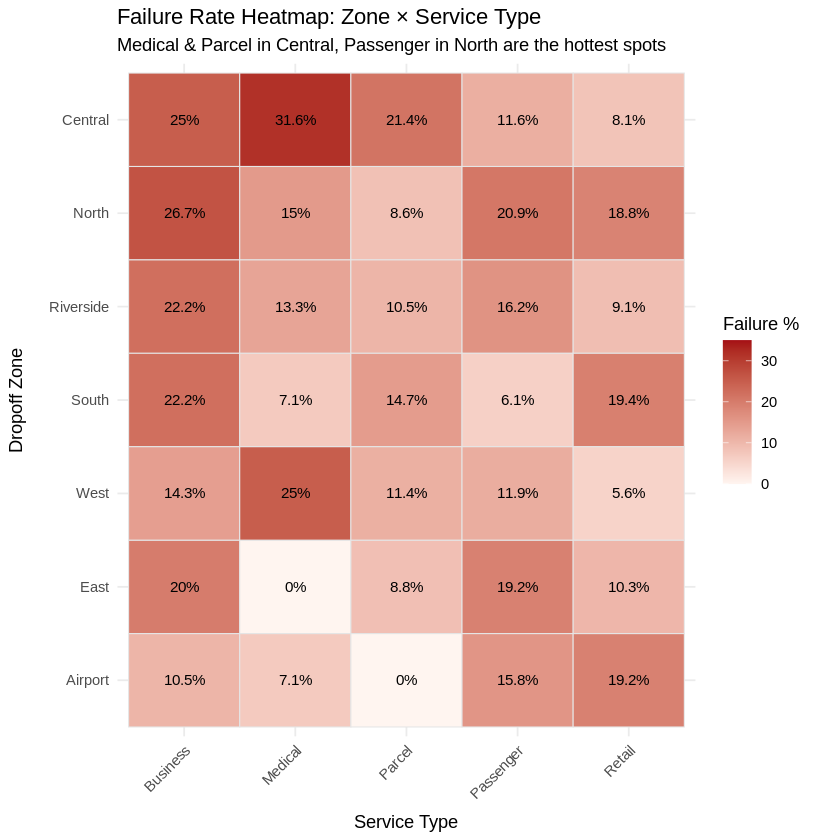

In [ ]:
heat_data <- master %>%
  filter(!is.na(delivery_status)) %>%                    # drop rows with no status
  group_by(dropoff_zone, service_type) %>%
  summarise(
    failure_pct = round(sum(delivery_status == "Failed", na.rm = TRUE) /
                        n() * 100, 1),
    .groups = "drop"
  )

ggplot(heat_data, aes(x = service_type, y = reorder(dropoff_zone, failure_pct),
                      fill = failure_pct)) +
  geom_tile(color = "grey90", linewidth = 0.3) +
  geom_text(aes(label = paste0(failure_pct, "%")), size = 3.2, color = "black") +
  scale_fill_gradient(low = "#FFF5F0", high = "#A50F15", name = "Failure %",
                      limits = c(0, 35)) +
  labs(title = "Failure Rate Heatmap: Zone × Service Type",
       subtitle = "Medical & Parcel in Central, Passenger in North are the hottest spots",
       x = "Service Type", y = "Dropoff Zone") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

Drivers of Customer Rating

In [ ]:
model <- lm(customer_rating_post_delivery ~ manual_route_override_count +
              route_distance_km + promised_window_hours + delivery_status,
            data = master)
summary(model)


Call:
lm(formula = customer_rating_post_delivery ~ manual_route_override_count + 
    route_distance_km + promised_window_hours + delivery_status, 
    data = master)

Residuals:
     Min       1Q   Median       3Q      Max 
-2.29483 -0.44811  0.02693  0.48624  1.95642 

Coefficients:
                             Estimate Std. Error t value Pr(>|t|)    
(Intercept)                  3.056281   0.071090  42.991   <2e-16 ***
manual_route_override_count -0.027994   0.021049  -1.330   0.1839    
route_distance_km            0.005369   0.003095   1.735   0.0831 .  
promised_window_hours        0.001539   0.003286   0.468   0.6396    
delivery_statusFailed       -0.060501   0.077767  -0.778   0.4368    
delivery_statusOnTime        1.166961   0.056643  20.602   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.6891 on 930 degrees of freedom
  (314 observations deleted due to missingness)
Multiple R-squared:  0.4096,	Adjusted R-squared: 